In [1]:
!pip install ultralytics -q
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, json, random, copy, shutil, zipfile, time
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import re as re_module

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.8 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA L4


## Config — set `RUN_LOOP` first

In [2]:
RUN_NAME = 'final_escalation_smoothed'

# One round = one month: the defender redeploys a new adversarial scheme monthly,
# so 12 rounds is a year of deployment.
N_ROUNDS = 12      
# ALLOW_TRAINING is set, so this can never start 11 hours by accident.                   
ALLOW_TRAINING = True

EPS = 4 / 255; ALPHA = 1 / 255; PGD_STEPS = 10; PGD_BATCH = 64; VLM_BATCH = 128
SEED = 42               # Universal default; the defender assumes the solver uses it
SEED_INDEPENDENT = 7    # Solver whose batch order the defender cannot reproduce
LR = 5e-5; EPOCHS = 10
N_TEST = 759; N_CLASSES = 13
N_PUZZLES = 1200
n_adv = N_PUZZLES * 9           

USE_REPLAY = True
REPLAY_CAP = 3000
ALIGNMENT_SAMPLE = 256             

MIN_IMAGES_PER_CLASS = 20          

SMOOTHING = 0.1

ARMS = ['surrogate', 'gt_solver', 'gt_independent', 'vlm_solver', 'vlm_independent']

ARM_LABELS    = {'surrogate': 'true', 'gt_solver': 'true', 'gt_independent': 'true',
                 'vlm_solver': 'vlm', 'vlm_independent': 'vlm'}
ARM_SEED      = {'surrogate': SEED, 'gt_solver': SEED, 'gt_independent': SEED_INDEPENDENT,
                 'vlm_solver': SEED, 'vlm_independent': SEED_INDEPENDENT}
ARM_SMOOTHING = {arm: SMOOTHING for arm in ARMS}

HEADLINE_ARMS = ['surrogate', 'gt_solver', 'vlm_solver'] 

print(f'folder      {RUN_NAME}')

folder      final_escalation_smoothed


## Drive, paths, and the overwrite guard

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR   = os.path.join('/content/drive/MyDrive', 'recaptcha dataset with rare samples')
OUT_DIR     = os.path.join(DRIVE_DIR, RUN_NAME)
RESUME_PATH = os.path.join(OUT_DIR, 'resume_state.pt')       

existing_stages = sorted((d for d in os.listdir(OUT_DIR) if d.startswith('stage')),
                         key=lambda name: int(name[5:])) if os.path.isdir(OUT_DIR) else []
rounds_on_disk = len(existing_stages)
needs_training = rounds_on_disk < N_ROUNDS

missing_validation = [k for k in range(rounds_on_disk)
                      if not os.path.exists(os.path.join(OUT_DIR, f'stage{k}',
                                                         'vlm_test_preds.json'))]

missing_clean_vlm = not os.path.exists(os.path.join(OUT_DIR, 'vlm_clean_preds.json'))
needs_vlm = needs_training or bool(missing_validation) or missing_clean_vlm

print(f'target: {OUT_DIR}')
print(f'  rounds on disk {rounds_on_disk}   requested {N_ROUNDS}')

if not needs_training:
    # Everything asked for already exists. Nothing is trained, VLM is never
    # loaded, and the cells below read from Drive.
    print(f'  nothing to train - reporting the first {N_ROUNDS} of '
          f'{rounds_on_disk} completed rounds')

    # An older run may not contain every arm this notebook now defines. Report the
    # ones it actually has rather than failing on a missing checkpoint.
    available = sorted(f[:-3] for f in os.listdir(os.path.join(OUT_DIR, 'stage0'))
                       if f.endswith('.pt') and f != 'test_advs.pt')
    dropped = [a for a in ARMS if a not in available]
    if dropped:
        print(f'  not present in this run, dropping: {", ".join(dropped)}')
        ARMS = [a for a in ARMS if a in available]
        HEADLINE_ARMS = [a for a in HEADLINE_ARMS if a in ARMS]
    print(f'  arms: {", ".join(ARMS)}')
    if missing_validation:
        print(f'  {len(missing_validation)} rounds still need the VLM scored on their '
              f'validation attacks (~{len(missing_validation) * 18 / 60:.0f} min)')
else:
    missing = N_ROUNDS - rounds_on_disk
    if not ALLOW_TRAINING:
        raise RuntimeError(
            f'{RUN_NAME} holds {rounds_on_disk} rounds; {N_ROUNDS} were requested.\n'
            f'  - for a different run:   change RUN_NAME')
    
    existing_config_path = os.path.join(OUT_DIR, 'config.json')
    if rounds_on_disk and os.path.exists(existing_config_path):
        existing_config = json.load(open(existing_config_path))
        for key, value in [('seed', SEED), ('seed_independent', SEED_INDEPENDENT),
                           ('replay_cap', REPLAY_CAP), ('epochs', EPOCHS), ('lr', LR),
                           ('smoothing', SMOOTHING), ('eps', EPS)]:
            if key in existing_config and existing_config[key] != value:
                raise RuntimeError(
                    f'{RUN_NAME} was trained with {key}={existing_config[key]}, but this '
                    f'notebook has {key}={value}.\n'
                    f'  - to continue that run:   set {key} = {existing_config[key]}\n')

    if rounds_on_disk and not os.path.exists(RESUME_PATH):
        raise RuntimeError(
            f'{RUN_NAME} holds {rounds_on_disk} stage directories but no resume_state.pt, '
            'so the buffers and weights cannot be restored. Use a fresh RUN_NAME.')

    os.makedirs(OUT_DIR, exist_ok=True)
    

    # Every parameter that affects the result, stored next to the result.
    json.dump(dict(n_rounds=N_ROUNDS, use_replay=USE_REPLAY, replay_cap=REPLAY_CAP,
                   seed=SEED, seed_solver=SEED, seed_defender=SEED,
                   seed_independent=SEED_INDEPENDENT, arms=ARMS,
                   smoothing=SMOOTHING, arm_labels=ARM_LABELS, arm_seed=ARM_SEED,
                   eps=EPS, alpha=ALPHA, pgd_steps=PGD_STEPS, lr=LR, epochs=EPOCHS,
                   n_puzzles=N_PUZZLES, n_test=N_TEST),
              open(os.path.join(OUT_DIR, 'config.json'), 'w'), indent=2)
    print(f'  wrote {RUN_NAME}/config.json')

Mounted at /content/drive
target: /content/drive/MyDrive/recaptcha dataset with rare samples/final_escalation_smoothed
  rounds on disk 12   requested 12
  nothing to train - reporting the first 12 of 12 completed rounds
  arms: surrogate, gt_solver, gt_independent, vlm_solver, vlm_independent


## Data preparation

In [4]:
DATASET_DIR = '/content/recaptcha-dataset-master'
TRAIN_DIR   = os.path.join(DATASET_DIR, 'Training')
VAL_DIR     = os.path.join(DATASET_DIR, 'Validation')

if not os.path.isdir(DATASET_DIR):
    with zipfile.ZipFile(os.path.join(DRIVE_DIR, 'recaptcha-dataset-master.zip'), 'r') as archive:
        archive.extractall('/content')

from ultralytics import YOLO
MODEL_PATH = '/content/classification_model.pt'
if not os.path.exists(MODEL_PATH):
    shutil.copy(os.path.join(DRIVE_DIR, 'classification_model.pt'), MODEL_PATH)

yolo = YOLO(MODEL_PATH)
base_model = yolo.model.to(device).eval()
class_name_to_index = {name: index for index, name in yolo.names.items()}
CLASS_NAMES = [yolo.names[i] for i in range(N_CLASSES)]

IMAGE_SIZE = 128
preprocess = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                                 transforms.ToTensor()])

import PIL.Image
open_image = PIL.Image.open.__wrapped__ if hasattr(PIL.Image.open, '__wrapped__') else PIL.Image.open


def forward_probs(model, images):
    output = model(images)
    return output[0] if isinstance(output, tuple) else output


def list_images(directory):
    """Enumerate one image record per file: {'path', 'label', 'class_name'}.

    Folders whose name is not one of the model's classes are skipped -- the
    dataset contains Boat, Taxi and Tractor, which this model cannot predict.
    """
    records = []
    for class_name in sorted(os.listdir(directory)):
        label = class_name_to_index.get(class_name, -1) # -1 = not a class we can predict
        class_dir = os.path.join(directory, class_name)
        if label == -1 or not os.path.isdir(class_dir):
            continue
        for filename in sorted(os.listdir(class_dir)):
            records.append({'path': os.path.join(class_dir, filename),
                            'label': label, 'class_name': class_name})
    return records


def load_image(path):
    try:
        return preprocess(open_image(path).convert('RGB'))
    except Exception:
        return None


# --- training set: CLASS-BALANCED sampling ------------------------------------

training_records = list_images(TRAIN_DIR)
validation_records = list_images(VAL_DIR)

records_by_class = defaultdict(list)
for record in training_records:
    records_by_class[record['class_name']].append(record)

selection_rng = random.Random(SEED)
per_class_quota = n_adv // N_CLASSES                 # 10800 // 13 = 830  (the remainder is dropped)
selected_records = []
for class_name in sorted(records_by_class):
    class_records = list(records_by_class[class_name])
    selection_rng.shuffle(class_records)
    if len(class_records) >= per_class_quota:
        selected_records.extend(class_records[:per_class_quota])
    else:
        # too few images: repeat the list and truncate. Those classes therefore
        # contain exact duplicates, which get attacked and sent to the VLM
        # several times per round.
        repeats = (per_class_quota // len(class_records)) + 1
        selected_records.extend((class_records * repeats)[:per_class_quota])

load_start = time.time()

clean_imgs, true_idxs = [], []
for record in selected_records:
    tensor = load_image(record['path'])
    if tensor is not None:
        if needs_training:
            clean_imgs.append(tensor)
        true_idxs.append(record['label'])

# --- test set: a seeded shuffle of the validation split -----------------------
random.seed(SEED)
torch.manual_seed(SEED)
shuffled_validation = list(validation_records)
random.shuffle(shuffled_validation)

test_clean, test_true = [], []
for record in shuffled_validation:
    if len(test_clean) >= N_TEST:
        break
    tensor = load_image(record['path'])
    if tensor is not None:
        test_clean.append(tensor)
        test_true.append(record['label'])

test_labels       = torch.tensor(test_true)  
test_clean_images = torch.stack(test_clean) 
print(f'classes ({N_CLASSES}): {", ".join(CLASS_NAMES)}')
print(f'train {len(clean_imgs)} | test {len(test_clean)} | loaded in {time.time() - load_start:.0f}s')

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
classes (13): Bicycle, Bridge, Bus, Car, Chimney, Crosswalk, Hydrant, Motorcycle, Mountain, Other, Palm, Stairs, Traffic Light
train 0 | test 759 | loaded in 15s


## VLM teacher

In [ ]:
if not needs_vlm:
    pass          
else:
    from transformers import AutoModelForImageTextToText, AutoProcessor
    from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

    print('loading the VLM ...')
    vlm = AutoModelForImageTextToText.from_pretrained(
        'Hcompany/Holo1-7B', torch_dtype='auto', device_map='auto')
    vlm_processor = AutoProcessor.from_pretrained('Hcompany/Holo1-7B', use_fast=True)
    vlm_processor.tokenizer.padding_side = 'left'      # required for batched generation

    PROMPT_CLASSES = ['Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk', 'Hydrant',
                      'Motorcycle', 'Mountain', 'Other', 'Palm', 'Traffic Light',
                      'Boat', 'Stairs', 'Taxi', 'Tractor']
    PROMPT_CLASS_TO_INDEX = {name: i for i, name in enumerate(PROMPT_CLASSES)}

    PROMPT = ('Look at this image carefully and identify what object you see.\n\n'
              'Choose ONLY ONE number from the following list:\n\n'
              '0: Bicycle\n1: Bridge\n2: Bus\n3: Car\n4: Chimney\n5: Crosswalk\n6: Hydrant\n'
              '7: Motorcycle\n8: Mountain\n9: Other\n10: Palm\n11: Traffic Light\n'
              '12: Boat\n13: Stairs\n14: Taxi\n15: Tractor\n\n'
              'Answer with ONLY the number (0-15) of the class you see with the highest confidence.\n'
              'Do not include any explanation, just the number.\n\nAnswer: ')


    def parse_reply(reply):
        """Turn the VLM's free text into a prompt-class index 0-15, or -1 if unusable."""
        numbers = re_module.findall(r'\b(\d{1,2})\b', reply.strip())
        if numbers:
            value = int(numbers[0])
            if 0 <= value <= 15:
                return value
        upper = reply.upper()
        for name, index in PROMPT_CLASS_TO_INDEX.items():
            if name.upper() in upper:
                return index
        return -1


    def resize_for_vlm(image):
        """Resize a PIL image to dimensions vision model accepts."""
        image_processor = vlm_processor.image_processor
        min_pixels = getattr(image_processor, 'min_pixels', None) or 3136
        max_pixels = getattr(image_processor, 'max_pixels', None) or 3145728
        factor = image_processor.patch_size * getattr(image_processor, 'merge_size', 1)
        height, width = smart_resize(image.height, image.width, factor=factor,
                                     min_pixels=min_pixels, max_pixels=max_pixels)
        return image.resize((width, height), Image.LANCZOS)      # PIL takes (w, h)


    def tensor_to_pil(tensor):
        """(3,H,W) float tensor in [0,1] -> PIL RGB image."""
        array = (tensor.clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        return Image.fromarray(array)


    def query_vlm(tensors, batch_size=VLM_BATCH, tag=''):
        """Label a list of image tensors with VLM."""
        images = [tensor_to_pil(t) for t in tensors]
        labels = []
        start_time = time.time()

        for start in range(0, len(images), batch_size):
            batch = [resize_for_vlm(image) for image in images[start:start + batch_size]]
            prompts = [vlm_processor.apply_chat_template(
                           [{'role': 'user',
                             'content': [{'type': 'image'}, {'type': 'text', 'text': PROMPT}]}],
                           tokenize=False, add_generation_prompt=True) for _ in batch]

            inputs = vlm_processor(text=prompts, images=batch, padding=True,
                                   return_tensors='pt').to('cuda')
            with torch.no_grad():
                generated = vlm.generate(**inputs, max_new_tokens=16)

            for i in range(len(batch)):
                reply = vlm_processor.decode(generated[i][len(inputs.input_ids[i]):],
                                             skip_special_tokens=True).strip()
                prompt_index = parse_reply(reply)
                labels.append(class_name_to_index.get(PROMPT_CLASSES[prompt_index], -1)
                              if prompt_index >= 0 else -1)
            del inputs, generated

        print(f'      VLM {tag}: {len(images)} in {time.time() - start_time:.0f}s')
        return labels


    print('VLM ready.')

## Attack / train / evaluate

In [6]:
# ---------------------------------------------------------------------------
# 1. PGD attack
# ---------------------------------------------------------------------------
def pgd_attack(model, images, labels, num_steps=PGD_STEPS, batch_size=PGD_BATCH):
    """Craft adversarial versions of images against model."""
    model.eval()                                    
    adversarial_images = []

    for start in range(0, len(images), batch_size):
        clean_batch = torch.stack(images[start:start + batch_size]).to(device)
        label_batch = torch.tensor(labels[start:start + batch_size], device=device)

        delta = ((torch.rand_like(clean_batch) * 2 - 1) * EPS)
        delta = delta.detach().requires_grad_(True) 

        for _ in range(num_steps):
            with torch.enable_grad():
                probabilities = forward_probs(model, torch.clamp(clean_batch + delta, 0, 1))
                loss = F.nll_loss(torch.log(probabilities + 1e-8), label_batch)
                grad_wrt_delta, = torch.autograd.grad(loss, delta)

            with torch.no_grad():
                delta.data += ALPHA * grad_wrt_delta.sign()
                delta.data.clamp_(-EPS, EPS)
                delta.data = torch.clamp(clean_batch + delta.data, 0, 1) - clean_batch

        adversarial_images.extend(
            torch.clamp(clean_batch + delta, 0, 1).detach().cpu().unbind(0))
        del clean_batch, label_batch, delta

    return adversarial_images


# ---------------------------------------------------------------------------
# 2. Dataset wrapper
# ---------------------------------------------------------------------------
class ImageLabelDataset(Dataset):
    """Wraps a list of (image_tensor, label_int) pairs for use with DataLoader."""

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        return self.pairs[index][0], self.pairs[index][1]


# ---------------------------------------------------------------------------
# 3. Retraining
# ---------------------------------------------------------------------------
def train_model(start_weights, training_pairs, seed, smoothing=0.0):
    """Fine-tune a copy for epochs."""
    # seed BEFORE any shuffling: both the explicit shuffle below and the
    # DataLoader's internal shuffling draw from these two generators
    random.seed(seed)
    torch.manual_seed(seed)

    training_pairs = list(training_pairs)
    random.shuffle(training_pairs)

    model = copy.deepcopy(start_weights).to(device)
    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(ImageLabelDataset(training_pairs), batch_size=64, shuffle=True)

    model.train()          
    for _ in range(EPOCHS):
        for image_batch, label_batch in loader:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)

            output = forward_probs(model, image_batch)

            if output.min() >= 0:
                loss = F.cross_entropy(torch.log(output + 1e-8), label_batch,
                                       label_smoothing=smoothing)
            else:
                loss = F.cross_entropy(output, label_batch, label_smoothing=smoothing)

            if torch.isnan(loss):
                continue        

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()           
    return model


# ---------------------------------------------------------------------------
# 4. Evaluation
# ---------------------------------------------------------------------------
@torch.no_grad()           # no gradients needed here; saves a lot of activation memory
def accuracy_on(model, images, batch_size=128):
    """Top-1 accuracy of model on images, scored against the global test_labels."""
    batch_tensor = torch.stack(images) if isinstance(images, list) else images
    num_eval = min(len(batch_tensor), len(test_labels))
    num_correct = 0

    for i in range(0, num_eval, batch_size):
        predictions = forward_probs(model, batch_tensor[i:i + batch_size].to(device)).argmax(1).cpu()
        num_correct += (predictions == test_labels[i:i + batch_size]).sum().item()

    return 100.0 * num_correct / num_eval


# ---------------------------------------------------------------------------
# 5. Replay buffer
# ---------------------------------------------------------------------------
def update_replay_buffer(buffer, new_items, round_index):
    """Merge this round's samples into the buffer."""
    if not USE_REPLAY:
        return buffer

    rng = random.Random(SEED + round_index)
    combined = buffer + new_items
    rng.shuffle(combined)
    return combined[:REPLAY_CAP]



# ---------------------------------------------------------------------------
# 6. Input-gradient alignment
# ---------------------------------------------------------------------------
def input_gradient(model, images, labels):
    """d(loss)/d(input), flattened. This is the direction an attacker follows."""
    model.eval()
    x = images.clone().to(device).requires_grad_(True)
    loss = F.nll_loss(torch.log(forward_probs(model, x) + 1e-8), labels.to(device))
    gradient, = torch.autograd.grad(loss, x)
    return gradient.flatten()


def alignment_with_surrogate(surrogate, model, images, labels):
    """Cosine similarity between two models' input gradients."""
    a = input_gradient(surrogate, images, labels)
    b = input_gradient(model, images, labels)
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

## The escalation loop

In [7]:
if not needs_training:
    results_per_round = json.load(open(os.path.join(OUT_DIR, 'results.json')))
else:
    # =======================================================================
    # THE ESCALATION LOOP
    #
    # One round models one month of an arms race:
    #
    #   1. The defender crafts PGD attacks against its surrogate, using the
    #      surrogate's weights.
    #   2. PRE-RECOVERY is measured: how each solver handles those attacks
    #      before it has seen them.
    #   3. VLM labels the attacked training images. The solver has no ground
    #      truth in reality.
    #   4. Every arm retrains on this round's attacks.
    #   5. POST-RECOVERY is measured on the SAME attacks, after retraining.
    #   6. Gradient alignment with the surrogate is recorded.
    #   7. This round's samples enter the buffers for future rounds.
    #
    # Every arm - the defender included - trains with label smoothing.
    # Arms differ ONLY in their labels, their seed, and GPU
    # nondeterminism.
    # =======================================================================

    models            = {arm: copy.deepcopy(base_model).to(device).eval() for arm in ARMS}
    replay_buffers    = {arm: [] for arm in ARMS}
    results_per_round = []
    first_round       = 0

    # a fixed sample, so alignment is comparable across rounds
    alignment_images = test_clean_images[:ALIGNMENT_SAMPLE]
    alignment_labels = test_labels[:ALIGNMENT_SAMPLE]

    if os.path.exists(RESUME_PATH):
        resume_state      = torch.load(RESUME_PATH, map_location='cpu')
        first_round       = resume_state['next_round']
        results_per_round = resume_state.get('rows', [])
        replay_buffers = {
            arm: [(image.float(), int(label))
                  for image, label in resume_state['bufs'].get(arm, [])] for arm in ARMS}
        previous_stage = os.path.join(OUT_DIR, f'stage{first_round - 1}')
        for arm in ARMS:
            models[arm].load_state_dict(
                torch.load(os.path.join(previous_stage, f'{arm}.pt'), map_location=device))
            models[arm].eval()
        print(f'RESUMED from round {first_round}')
    else:
        print('starting fresh')

    json.dump({'labels': [int(v) for v in true_idxs]},
              open(os.path.join(OUT_DIR, 'train_labels.json'), 'w'))

    print('\n' + '=' * 118)
    print(f'ESCALATION, SMOOTHING DEFAULT  ({N_ROUNDS} rounds, {len(ARMS)} arms, '
          f'smoothing={SMOOTHING}, seeds {SEED}/{SEED_INDEPENDENT})')
    print('=' * 118)
    if first_round == 0:
        print('  arm columns and VLM: accuracy on the 759 VALIDATION attacks')
        print(f'{"rnd":>4} | ' + ' '.join(f'{arm[:9]:>9}' for arm in ARMS) + ' |     VLM')
        print('-' * 118)

    for round_index in range(first_round, N_ROUNDS):
        round_start_time = time.time()
        stage_dir = os.path.join(OUT_DIR, f'stage{round_index}')
        os.makedirs(stage_dir, exist_ok=True)

        # ---------------------------------------------------------------
        # STEP 1 - the defender attacks with its weights as they stand now
        # ---------------------------------------------------------------
        torch.manual_seed(SEED + 10_000 + round_index)

        surrogate = models['surrogate']
        train_adversarial = pgd_attack(surrogate, clean_imgs, true_idxs)
        test_adversarial  = pgd_attack(surrogate, test_clean, test_true)
        torch.save(test_adversarial, os.path.join(stage_dir, 'test_advs.pt'))

        validation_cache = os.path.join(stage_dir, 'vlm_test_preds.json')
        if os.path.exists(validation_cache):
            vlm_validation = json.load(open(validation_cache))['labels']
        else:
            vlm_validation = query_vlm(test_adversarial, tag=f'val r{round_index}')
            json.dump({'labels': vlm_validation}, open(validation_cache, 'w'))
        vlm_validation_accuracy = 100.0 * sum(
            1 for predicted, actual in zip(vlm_validation, test_true)
            if predicted == actual) / max(1, len(vlm_validation))

        # ---------------------------------------------------------------
        # STEP 2 - PRE-RECOVERY: every arm still holds last round's weights
        # ---------------------------------------------------------------
        pre_recovery_accuracy = {arm: accuracy_on(models[arm], test_adversarial)
                                 for arm in ARMS}

        # ---------------------------------------------------------------
        # STEP 3 - the VLM labels the attacked training images.
        # 11k queries dominate the runtime, so they are cached. 
        # ---------------------------------------------------------------
        vlm_cache_path = os.path.join(stage_dir, 'vlm_preds.json')
        stride = max(1, len(train_adversarial) // 50)
        fingerprint = float(sum(float(train_adversarial[i].sum())
                                for i in range(0, len(train_adversarial), stride)))
        vlm_labels = None
        if os.path.exists(vlm_cache_path):
            cached = json.load(open(vlm_cache_path))
            if abs(cached.get('fingerprint', float('inf')) - fingerprint) \
                    < 1e-3 * max(1.0, abs(fingerprint)):
                vlm_labels = cached['labels']
        if vlm_labels is None:
            vlm_labels = query_vlm(train_adversarial, tag=f'r{round_index}')
            json.dump({'labels': vlm_labels, 'fingerprint': fingerprint},
                      open(vlm_cache_path, 'w'))

        vlm_label_accuracy = 100.0 * sum(1 for predicted, actual in zip(vlm_labels, true_idxs)
                                         if predicted == actual) / max(1, len(vlm_labels))

        # ---------------------------------------------------------------
        # STEP 4 - build the two training sets, then retrain every arm.
        #
        # Every arm trains on adversarial AND clean images, so that defending
        # against the attack does not destroy clean accuracy.
        #
        # On clean_with_vlm_labels: the clean image inherits the VLM's
        # prediction on its ADVERSARIAL counterpart. The VLM is never queried on
        # clean images, so the VLM arms train on clean data with ~70%-accurate
        # labels. 
        # ---------------------------------------------------------------
        adv_with_true_labels   = [(train_adversarial[i], true_idxs[i])
                                  for i in range(len(train_adversarial))]
        clean_with_true_labels = [(clean_imgs[i], true_idxs[i])
                                  for i in range(len(clean_imgs))]
        adv_with_vlm_labels    = [(train_adversarial[i], vlm_labels[i])
                                  for i in range(len(train_adversarial)) if vlm_labels[i] >= 0]
        clean_with_vlm_labels  = [(clean_imgs[i], vlm_labels[i])
                                  for i in range(len(clean_imgs)) if vlm_labels[i] >= 0]

        training_data = {'true': adv_with_true_labels + clean_with_true_labels,
                         'vlm':  adv_with_vlm_labels  + clean_with_vlm_labels}

        for arm in ARMS:
            # the buffer here is from PREVIOUS rounds; this round's samples are
            # added in step 7, so an arm never replays what it is training on
            models[arm] = train_model(models[arm],
                                      training_data[ARM_LABELS[arm]] + replay_buffers[arm],
                                      ARM_SEED[arm], ARM_SMOOTHING[arm])
            torch.save(models[arm].state_dict(), os.path.join(stage_dir, f'{arm}.pt'))

        # ---------------------------------------------------------------
        # STEP 5 - POST-RECOVERY: same attacks, retrained weights
        # ---------------------------------------------------------------
        post_recovery_accuracy = {arm: accuracy_on(models[arm], test_adversarial)
                                  for arm in ARMS}

        # ---------------------------------------------------------------
        # STEP 6 - how closely each arm's loss points the defender's
        # ---------------------------------------------------------------
        gradient_alignment = {
            arm: alignment_with_surrogate(models['surrogate'], models[arm],
                                          alignment_images, alignment_labels)
            for arm in ARMS}

        # ---------------------------------------------------------------
        # STEP 7 - this round's samples enter the buffers, for round k+1
        # ---------------------------------------------------------------
        for arm in ARMS:
            new_items = (adv_with_vlm_labels if ARM_LABELS[arm] == 'vlm'
                         else adv_with_true_labels)
            replay_buffers[arm] = update_replay_buffer(replay_buffers[arm], new_items,
                                                       round_index)

        results_per_round.append(dict(round=round_index,
                                      pre=pre_recovery_accuracy,
                                      post=post_recovery_accuracy,
                                      align=gradient_alignment,
                                      vlm_train_acc=vlm_label_accuracy,
                                      vlm_test_acc=vlm_validation_accuracy))

        torch.save({'next_round': round_index + 1,
                    'rows': results_per_round,
                    'bufs': {arm: [(image.half(), int(label))
                                   for image, label in replay_buffers[arm]] for arm in ARMS}},
                   RESUME_PATH)
        json.dump(results_per_round, open(os.path.join(OUT_DIR, 'results.json'), 'w'),
                  indent=2, default=float)

        print(f'{round_index:>4} | '
              + ' '.join(f'{pre_recovery_accuracy[arm]:>8.1f}%' for arm in ARMS)
              + f' | {vlm_validation_accuracy:>6.1f}%   ({time.time() - round_start_time:.0f}s)')

        del train_adversarial, test_adversarial
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print('\nloop complete.')

rounds_on_disk = len([d for d in os.listdir(OUT_DIR) if d.startswith('stage')])


In [8]:
# Clean reference, queried once: the VLM on the 759 UNATTACKED validation images.
clean_vlm_path = os.path.join(OUT_DIR, 'vlm_clean_preds.json')
if os.path.exists(clean_vlm_path):
    print('clean VLM predictions already cached')
else:
    clean_labels = np.array(query_vlm(test_clean, tag='clean'))
    json.dump({'labels': clean_labels.tolist()}, open(clean_vlm_path, 'w'))


if not missing_validation:
    pass          # every round already scored
else:
    validation_labels = np.array(test_true)
    start_time = time.time()
    for k in missing_validation:
        saved = torch.load(os.path.join(OUT_DIR, f'stage{k}', 'test_advs.pt'),
                           map_location='cpu')
        attacks = torch.stack(saved) if isinstance(saved, list) else saved
        labels = query_vlm(list(attacks.unbind(0)), tag=f'val r{k}')
        json.dump({'labels': labels}, open(os.path.join(OUT_DIR, f'stage{k}',
                                                        'vlm_test_preds.json'), 'w'))
        if k % 10 == 0:
            print(f'  round {k}: {100.0 * (np.array(labels) == validation_labels).mean():.1f}%  '
                  f'({time.time() - start_time:.0f}s elapsed)')
    print(f'scored {len(missing_validation)} rounds in {time.time() - start_time:.0f}s')

clean VLM predictions already cached


In [9]:
# Checkpoint loaders. They live here because c-cascade reads every stage's weights
# and every round's attacks through them.
def load_checkpoint(round_index, arm):
    model = copy.deepcopy(base_model).to(device)
    model.load_state_dict(torch.load(os.path.join(OUT_DIR, f'stage{round_index}', f'{arm}.pt'),
                                     map_location=device))
    return model.eval()


def load_attacks(round_index):
    """The 759 test attacks crafted against stage{round_index - 1}'s surrogate."""
    saved = torch.load(os.path.join(OUT_DIR, f'stage{round_index}', 'test_advs.pt'),
                       map_location='cpu')
    return torch.stack(saved) if isinstance(saved, list) else saved



n_rounds = min(N_ROUNDS, len(results_per_round))
results_per_round = results_per_round[:n_rounds]
rounds = np.arange(n_rounds)
aggregate_pre  = {arm: np.array([r['pre'][arm]  for r in results_per_round], float)[:n_rounds]
                  for arm in ARMS}
aggregate_post = {arm: np.array([r['post'][arm] for r in results_per_round], float)[:n_rounds]
                  for arm in ARMS}

images_per_class = np.bincount(np.array(test_true), minlength=N_CLASSES).astype(float)
print('test-set composition:')
print('  ' + '  '.join(f'{name}:{int(count)}'
                       for name, count in zip(CLASS_NAMES, images_per_class)))
sparse = [f'{CLASS_NAMES[i]} n={int(images_per_class[i])}'
          for i in range(N_CLASSES) if images_per_class[i] < MIN_IMAGES_PER_CLASS]
if sparse:
    print(f'  fewer than {MIN_IMAGES_PER_CLASS} test images: ' + ', '.join(sparse))

test-set composition:
  Bicycle:74  Bridge:74  Bus:74  Car:74  Chimney:17  Crosswalk:74  Hydrant:74  Motorcycle:74  Mountain:2  Other:74  Palm:74  Stairs:0  Traffic Light:74
  fewer than 20 test images: Chimney n=17, Mountain n=2, Stairs n=0


In [10]:
validation_labels = np.array(test_true)
vlm_validation_accuracy = np.full(n_rounds, np.nan)
for k in range(n_rounds):
    path = os.path.join(OUT_DIR, f'stage{k}', 'vlm_test_preds.json')
    if os.path.exists(path):
        predicted = np.array(json.load(open(path))['labels'])
        vlm_validation_accuracy[k] = 100.0 * (predicted == validation_labels).mean()
have_vlm_scores = bool(np.isfinite(vlm_validation_accuracy).any())

## The deployed cascade under attack


In [11]:
ROUTING_THRESHOLD = 0.70          # route to the VLM below this YOLO confidence
CASCADE_CACHE = os.path.join(OUT_DIR, 'cascade_scan.json')


@torch.no_grad()
def predict_with_confidence(model, images, batch_size=128):
    """Returns (predicted_class, max_probability) per image."""
    predictions, confidences = [], []
    for i in range(0, len(images), batch_size):
        probabilities = forward_probs(model, images[i:i + batch_size].to(device)).cpu()
        predictions.append(probabilities.argmax(1).numpy())
        confidences.append(probabilities.max(1).values.numpy())
    return np.concatenate(predictions), np.concatenate(confidences)


if os.path.exists(CASCADE_CACHE):
    cached = json.load(open(CASCADE_CACHE))
    yolo_prediction = {st: {a: {int(k): np.array(v) for k, v in cached['pred'][st][a].items()}
                            for a in ARMS} for st in ['pre', 'post', 'clean']}
    yolo_confidence = {st: {a: {int(k): np.array(v, float)
                                for k, v in cached['conf'][st][a].items()}
                            for a in ARMS} for st in ['pre', 'post', 'clean']}
else:
    yolo_prediction = {st: {a: {} for a in ARMS} for st in ['pre', 'post', 'clean']}
    yolo_confidence = {st: {a: {} for a in ARMS} for st in ['pre', 'post', 'clean']}
    scan_start = time.time()

    next_attacks = load_attacks(0)
    for arm in ARMS:                       # round 0 pre: every arm is still the base model
        yolo_prediction['pre'][arm][0], yolo_confidence['pre'][arm][0] = \
            predict_with_confidence(base_model, next_attacks)

    for k in range(rounds_on_disk):
        current_attacks = next_attacks
        next_attacks = load_attacks(k + 1) if k + 1 < rounds_on_disk else None
        for arm in ARMS:
            model = load_checkpoint(k, arm)
            yolo_prediction['post'][arm][k], yolo_confidence['post'][arm][k] = \
                predict_with_confidence(model, current_attacks)
            if next_attacks is not None:
                yolo_prediction['pre'][arm][k + 1], yolo_confidence['pre'][arm][k + 1] = \
                    predict_with_confidence(model, next_attacks)
            yolo_prediction['clean'][arm][k], yolo_confidence['clean'][arm][k] = \
                predict_with_confidence(model, test_clean_images)
            del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if k % 10 == 0:
            print(f'  stage {k}/{rounds_on_disk - 1}  ({time.time() - scan_start:.0f}s)')

    json.dump(dict(pred={st: {a: {str(k): v.tolist() for k, v in yolo_prediction[st][a].items()}
                              for a in ARMS} for st in ['pre', 'post', 'clean']},
                   conf={st: {a: {str(k): v.tolist() for k, v in yolo_confidence[st][a].items()}
                              for a in ARMS} for st in ['pre', 'post', 'clean']}),
              open(CASCADE_CACHE, 'w'))
    print(f'cascade scan complete in {time.time() - scan_start:.0f}s -> cascade_scan.json')


validation_labels = np.array(test_true)
vlm_adversarial = {k: np.array(json.load(open(os.path.join(
                       OUT_DIR, f'stage{k}', 'vlm_test_preds.json')))['labels'])
                   for k in range(n_rounds)}
vlm_clean = np.array(json.load(open(os.path.join(OUT_DIR, 'vlm_clean_preds.json')))['labels']) \
    if os.path.exists(os.path.join(OUT_DIR, 'vlm_clean_preds.json')) else None


def apply_cascade(predictions, confidences, vlm_labels, threshold=ROUTING_THRESHOLD):
    """The deployed rule: keep YOLO above the threshold, route to the VLM below it."""
    triggered = confidences < threshold
    routed = triggered & (vlm_labels >= 0)
    final = predictions.copy()
    final[routed] = vlm_labels[routed]
    return final, routed, triggered

CASCADE_ARMS = [a for a in ['gt_solver', 'gt_independent', 'vlm_solver',
                            'vlm_independent', 'gt_smoothed', 'vlm_smoothed'] if a in ARMS]

def cascade_metrics(arm, k, state='pre', threshold=ROUTING_THRESHOLD):
    """(yolo_accuracy, cascade_accuracy, percent_routed, route_all_accuracy)"""
    predictions = yolo_prediction[state][arm][k]
    confidences = yolo_confidence[state][arm][k]
    vlm_labels  = vlm_clean if state == 'clean' else vlm_adversarial[k]
    final, _, triggered = apply_cascade(predictions, confidences, vlm_labels, threshold)
    route_all = predictions.copy()
    route_all[vlm_labels >= 0] = vlm_labels[vlm_labels >= 0]
    return (100 * (predictions == validation_labels).mean(),
            100 * (final       == validation_labels).mean(),
            100 * triggered.mean(),
            100 * (route_all   == validation_labels).mean())

late = range(max(0, n_rounds - 10), n_rounds)
print()
print('=' * 92)
print(f'THE CASCADE  (threshold={ROUTING_THRESHOLD}, last {len(late)} rounds, pre-recovery)')
print('=' * 92)
print(f'  {"arm":>16} {"YOLO":>7} {"cascade":>9} {"gain":>7} {"routed":>8} '
      f'{"route-all":>11} {"forgone":>9}')
for arm in CASCADE_ARMS:
    yolo_acc, casc_acc, routed, ceiling = np.array(
        [cascade_metrics(arm, k) for k in late]).mean(0)
    print(f'  {arm:>16} {yolo_acc:>6.1f}% {casc_acc:>8.1f}% {casc_acc - yolo_acc:>+6.1f} '
          f'{routed:>7.1f}% {ceiling:>10.1f}% {ceiling - casc_acc:>+8.1f}')

for arm in CASCADE_ARMS:
    clean_rate = np.mean([100 * (yolo_confidence['clean'][arm][k] < ROUTING_THRESHOLD).mean()
                          for k in late])
    adv_rate = np.mean([cascade_metrics(arm, k)[2] for k in late])
    print(f'  {arm:>16} {clean_rate:>7.1f}% {adv_rate:>12.1f}%')
print(f'  {"arm":>16} {"conf >= 0.99":>13} {"conf == 1.0":>12}')
for arm in CASCADE_ARMS:
    conf = np.concatenate([yolo_confidence['pre'][arm][k] for k in late])
    print(f'  {arm:>16} {100 * (conf >= 0.99).mean():>12.1f}% '
          f'{100 * (conf >= 1.0).mean():>11.1f}%')


# ---------------------------------------------------------------------------
# Would a fixed BUDGET beat the threshold?
# ---------------------------------------------------------------------------
def budget_cascade(arm, k, budget, state='pre'):
    """Route the least-confident budget fraction, whatever their confidences are."""
    confidences = yolo_confidence[state][arm][k]
    predictions = yolo_prediction[state][arm][k]
    vlm_labels  = vlm_clean if state == 'clean' else vlm_adversarial[k]

    n_route = int(round(budget * len(confidences)))
    least_confident = np.argsort(confidences)[:n_route]      # ties broken arbitrarily
    usable = least_confident[vlm_labels[least_confident] >= 0]

    final = predictions.copy()
    final[usable] = vlm_labels[usable]
    return 100 * (final == validation_labels).mean()


print()
print('=' * 92)
print('BUDGET ROUTING  (route the least-confident N%, instead of a confidence threshold)')
print('=' * 92)
print(f'  {"arm":>16} | {"threshold 0.70":>22} | {"budget at the SAME %":>21} | '
      f'{"10%":>7} {"20%":>7} {"30%":>7} | {"ceiling":>8}')
print('  ' + '-' * 96)
for arm in CASCADE_ARMS:
    yolo_acc, threshold_acc, routed, ceiling = np.array(
        [cascade_metrics(arm, k) for k in late]).mean(0)
    matched = np.mean([budget_cascade(arm, k, routed / 100) for k in late])
    at_10   = np.mean([budget_cascade(arm, k, 0.10) for k in late])
    at_20   = np.mean([budget_cascade(arm, k, 0.20) for k in late])
    at_30   = np.mean([budget_cascade(arm, k, 0.30) for k in late])
    print(f'  {arm:>16} | {threshold_acc:>6.1f}% at {routed:>4.1f}% routed | '
          f'{matched:>6.1f}%  ({matched - threshold_acc:>+5.1f}) | '
          f'{at_10:>6.1f}% {at_20:>6.1f}% {at_30:>6.1f}% | {ceiling:>7.1f}%')



# ---------------------------------------------------------------------------
# The cascade round by round.
# ---------------------------------------------------------------------------
per_round = {arm: np.array([cascade_metrics(arm, k) for k in range(n_rounds)])
             for arm in CASCADE_ARMS}      # columns: yolo, cascade, routed, ceiling

for column_index, column_name in [(1, 'CASCADE ACCURACY'), (0, 'YOLO ALONE'),
                                  (2, 'ROUTED %')]:
    print()
    print('=' * 92)
    print(f'{column_name} BY ROUND  (threshold={ROUTING_THRESHOLD}, pre-recovery)')
    print('=' * 92)
    print(f'  {"round":>5} | ' + ' | '.join(f'{arm[:15]:>15}' for arm in CASCADE_ARMS))
    print('  ' + '-' * (8 + 18 * len(CASCADE_ARMS)))
    for k in range(n_rounds):
        marker = '  <- warmup, excluded from the mean' if k < n_rounds - 10 else ''
        print(f'  {k:>5} | ' + ' | '.join(
            f'{per_round[arm][k, column_index]:>14.1f}%' for arm in CASCADE_ARMS) + marker)
    print('  ' + '-' * (8 + 18 * len(CASCADE_ARMS)))
    print(f'  {"mean":>5} | ' + ' | '.join(
        f'{per_round[arm][list(late), column_index].mean():>14.1f}%'
        for arm in CASCADE_ARMS) + f'   <- rounds {late[0]}-{late[-1]}')
    print(f'  {"last":>5} | ' + ' | '.join(
        f'{per_round[arm][n_rounds - 1, column_index]:>14.1f}%'
        for arm in CASCADE_ARMS) + f'   <- round {n_rounds - 1} alone')


print(f'  {"arm":>16} | {"cascade mean":>13} {"summary":>9} {"diff":>7} | '
      f'{"last round":>11} {"vs mean":>8}')
largest_drift = 0.0
for arm in CASCADE_ARMS:
    from_rounds = per_round[arm][list(late), 1].mean()
    from_summary = np.array([cascade_metrics(arm, k) for k in late]).mean(0)[1]
    last_round = per_round[arm][n_rounds - 1, 1]
    largest_drift = max(largest_drift, abs(from_rounds - from_summary))
    print(f'  {arm:>16} | {from_rounds:>12.2f}% {from_summary:>8.2f}% '
          f'{from_rounds - from_summary:>+6.2f} | {last_round:>10.1f}% '
          f'{last_round - from_rounds:>+7.1f}')
print()
if largest_drift < 0.005:
    print(f'  the two agree to {largest_drift:.4f} pp - the summary table averages exactly')
    print(f'  rounds {late[0]}-{late[-1]}, as intended.')
else:
    print(f'  MISMATCH of {largest_drift:.3f} pp - the averaging windows differ. Check your results.')


THE CASCADE  (threshold=0.7, last 10 rounds, pre-recovery)
               arm    YOLO   cascade    gain   routed   route-all   forgone
         gt_solver   28.4%     39.6%  +11.2    29.1%       75.4%    +35.9
    gt_independent   52.9%     66.3%  +13.4    40.0%       75.5%     +9.2
        vlm_solver   58.2%     70.2%  +12.0    45.7%       75.4%     +5.2
   vlm_independent   58.9%     71.0%  +12.1    44.8%       75.4%     +4.4
         gt_solver    35.1%         29.1%
    gt_independent    33.4%         40.0%
        vlm_solver    38.9%         45.7%
   vlm_independent    38.3%         44.8%
               arm  conf >= 0.99  conf == 1.0
         gt_solver         11.5%         0.0%
    gt_independent          0.2%         0.0%
        vlm_solver          0.1%         0.0%
   vlm_independent          0.1%         0.0%

BUDGET ROUTING  (route the least-confident N%, instead of a confidence threshold)
               arm |         threshold 0.70 |  budget at the SAME % |     10%     20%  

## Table II under attack

In [12]:
# ---------------------------------------------------------------------------
# The paper's Table II, under attack.
# ---------------------------------------------------------------------------
LATENCY_YOLO = 4.0        # ms per cell, from Table II
LATENCY_VLM  = 225.0      # ms per cell, from Table II

REPORT_ARM   = 'vlm_solver'
REPORT_ROUND = n_rounds - 1

if vlm_clean is None:
    print('vlm_clean_preds.json missing.')   
else:
    base_clean_prediction, base_clean_confidence = predict_with_confidence(
        base_model, test_clean_images)

    def overall_accuracy(predictions):
        """Frequency-weighted top-1."""
        return 100.0 * (predictions == validation_labels).mean()

    def macro_accuracy(predictions, min_support=1):
        """Unweighted mean of per-class recall"""
        recalls = [(predictions[validation_labels == c] == c).mean()
                   for c in range(N_CLASSES)
                   if (validation_labels == c).sum() >= min_support]
        return 100.0 * float(np.mean(recalls)), len(recalls)

    def measure(predictions, confidences, vlm_labels):
        hybrid, _routed, triggered = apply_cascade(
            predictions, confidences, vlm_labels, ROUTING_THRESHOLD)
        routed_fraction = float(triggered.mean())
        return dict(yolo_overall=overall_accuracy(predictions),
                    vlm_overall=overall_accuracy(vlm_labels),
                    hybrid_overall=overall_accuracy(hybrid),
                    yolo_macro=macro_accuracy(predictions)[0],
                    vlm_macro=macro_accuracy(vlm_labels)[0],
                    hybrid_macro=macro_accuracy(hybrid)[0],
                    routed=100.0 * routed_fraction,
                    latency=LATENCY_YOLO + routed_fraction * LATENCY_VLM,
                    abstained=100.0 * (vlm_labels < 0).mean())

    attacked = {
        'no defence':      measure(yolo_prediction['pre'][REPORT_ARM][0],
                                   yolo_confidence['pre'][REPORT_ARM][0],
                                   vlm_adversarial[0]),
        'after 12 rounds': measure(yolo_prediction['pre'][REPORT_ARM][REPORT_ROUND],
                                   yolo_confidence['pre'][REPORT_ARM][REPORT_ROUND],
                                   vlm_adversarial[REPORT_ROUND]),
    }

    _, n_scored = macro_accuracy(base_clean_prediction)
    print('=' * 86)
    print(f'TABLE II UNDER ATTACK   ({len(validation_labels)} images, {N_CLASSES} classes, '
          f'macro over {n_scored} with test images)')
    print(f'arm={REPORT_ARM}, round {REPORT_ROUND}, pre-recovery, threshold={ROUTING_THRESHOLD}')
    print('=' * 86)
    print(f'  {"metric":>30} | {"YOLO":>9} | {"VLM":>9} | {"Hybrid":>9}')
    print('  ' + '-' * 66)
    for condition, r in attacked.items():
        print(f'  {"Overall Acc. (" + condition + ")":>30} | {r["yolo_overall"]:>8.1f}% | '
              f'{r["vlm_overall"]:>8.1f}% | {r["hybrid_overall"]:>8.1f}%')
    for condition, r in attacked.items():
        print(f'  {"Macro Acc. (" + condition + ")":>30} | {r["yolo_macro"]:>8.1f}% | '
              f'{r["vlm_macro"]:>8.1f}% | {r["hybrid_macro"]:>8.1f}%')

    print('  ' + '-' * 66)
    for condition, r in attacked.items():
        print(f'  {"VLM calls (" + condition + ")":>30} | {"0%":>9} | {"100%":>9} | '
              f'{r["routed"]:>8.1f}%')
    for condition, r in attacked.items():
        print(f'  {"Avg. latency (" + condition + ")":>30} | {LATENCY_YOLO:>6.0f} ms | '
              f'{LATENCY_VLM:>6.0f} ms | {r["latency"]:>6.0f} ms')
    # Clean routing is deliberately NOT reported. Table II's 30% VLM calls is measured
    # on the 16-class set, where Boat/Taxi/Tractor tiles - classes this classifier has
    # no output for - sit at low confidence and inflate the routing rate. On this
    # 13-class basis those tiles are absent, so a clean routing figure computed here
    # is not comparable to the published one and would only introduce a false comparison.

    # --- what actually caused the clean-accuracy loss? -------------------------
    # gt_solver trains on TRUE labels, so its clean drop isolates the cost of
    # adversarial training. 
    if 'gt_solver' in ARMS:
        shipped_clean = overall_accuracy(base_clean_prediction)
        gt_clean      = overall_accuracy(yolo_prediction['clean']['gt_solver'][REPORT_ROUND])
        vlm_arm_clean = overall_accuracy(yolo_prediction['clean'][REPORT_ARM][REPORT_ROUND])
        print()
        print('  clean accuracy of YOLO alone at round 12:')
        print(f'    shipped model                           {shipped_clean:>5.1f}%')
        print(f'    after adversarial training, TRUE labels {gt_clean:>5.1f}%   '
              f'({gt_clean - shipped_clean:>+5.1f}  = cost of the defence)')
        print(f'    after adversarial training, VLM labels  {vlm_arm_clean:>5.1f}%   '
              f'({vlm_arm_clean - gt_clean:>+5.1f}  = cost of having no ground truth)')

    # --- LaTeX, ready to paste ------------------------------------------------
    print()
    print('-' * 86)
    print('Latex rows (adversarial only):')
    print('-' * 86)
    for label, key in [('Overall Acc.', 'overall'), ('Macro Acc.', 'macro')]:
        for condition, r in attacked.items():
            print(f'{label} ({condition}) & {r["yolo_" + key] / 100:.4f} & '
                  f'{r["vlm_" + key] / 100:.4f} & {r["hybrid_" + key] / 100:.4f} \\\\')
    for condition, r in attacked.items():
        print(f'VLM calls ({condition}) & 0\\% & 100\\% & {r["routed"]:.1f}\\% \\\\')
    for condition, r in attacked.items():
        print(f'Avg. latency ({condition}) & {LATENCY_YOLO:.0f} ms & {LATENCY_VLM:.0f} ms & '
              f'{r["latency"]:.0f} ms \\\\')

TABLE II UNDER ATTACK   (759 images, 13 classes, macro over 12 with test images)
arm=vlm_solver, round 11, pre-recovery, threshold=0.7
                          metric |      YOLO |       VLM |    Hybrid
  ------------------------------------------------------------------
       Overall Acc. (no defence) |      0.0% |     75.4% |      0.1%
  Overall Acc. (after 12 rounds) |     61.8% |     76.7% |     72.6%
         Macro Acc. (no defence) |      0.0% |     73.8% |      0.1%
    Macro Acc. (after 12 rounds) |     55.8% |     74.9% |     71.0%
  ------------------------------------------------------------------
          VLM calls (no defence) |        0% |      100% |      0.3%
     VLM calls (after 12 rounds) |        0% |      100% |     41.6%
       Avg. latency (no defence) |      4 ms |    225 ms |      5 ms
  Avg. latency (after 12 rounds) |      4 ms |    225 ms |     98 ms

  clean accuracy of YOLO alone at round 12:
    shipped model                            82.9%
    after 

## Controlled Experiment Figure

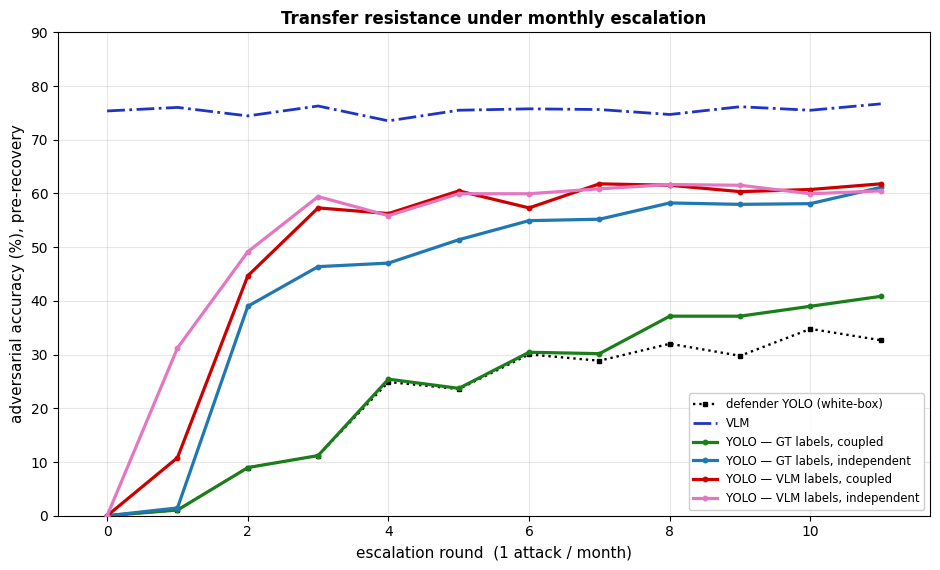

saved fig_seed_control.pdf

defender vs its own attacks, white-box, last 10 rounds: 25.7%
recovery gain (post minus pre, rounds 2+) - not plotted, one number per arm:
         gt_solver  +31.7 pp
    gt_independent  +11.3 pp
        vlm_solver   +4.1 pp
   vlm_independent   +3.4 pp

per-round pre -> post recovery:
  round |       surrogate |       gt_solver |  gt_independent |      vlm_solver | vlm_independent
  --------------------------------------------------------------------------------------------------
      1 |    1.1 ->  67.1 |    1.1 ->  66.9 |    1.4 ->  65.0 |   10.8 ->  60.3 |   31.2 ->  60.9
      2 |    9.0 ->  69.2 |    9.0 ->  69.3 |   39.0 ->  66.3 |   44.7 ->  59.2 |   49.1 ->  60.1
      3 |   11.2 ->  65.2 |   11.2 ->  65.2 |   46.4 ->  67.3 |   57.3 ->  64.0 |   59.4 ->  64.8
      5 |   23.6 ->  59.7 |   23.7 ->  59.4 |   51.4 ->  64.6 |   60.5 ->  64.4 |   59.9 ->  65.3
     10 |   34.8 ->  51.4 |   39.0 ->  55.7 |   58.1 ->  62.5 |   60.7 ->  61.9 |   59.9 ->  

In [13]:
CONTROL = [(a, colour, label) for a, colour, label in [
    ('gt_solver',       '#1a7f1a', 'YOLO — GT labels, coupled'),
    ('gt_independent',  '#1f77b4', 'YOLO — GT labels, independent'),
    ('vlm_solver',      '#cc0000', 'YOLO — VLM labels, coupled'),
    ('vlm_independent', '#e377c2', 'YOLO — VLM labels, independent'),
    ('gt_smoothed',     '#ff7f0e', 'YOLO — GT labels, smoothed')] if a in ARMS]

figure, axis = plt.subplots(figsize=(9.5, 5.8))

axis.plot(rounds, aggregate_pre['surrogate'], color='black', lw=1.7, ls=':', marker='s',
          ms=3, zorder=2, label='defender YOLO (white-box)')

# the VLM component itself: never attacked, so close to flat
if have_vlm_scores:
    axis.plot(rounds, vlm_validation_accuracy, color='#1e34c6', lw=2.0, ls='-.',
              zorder=4, label='VLM')

for arm, colour, label in CONTROL:
    axis.plot(rounds, aggregate_pre[arm], color=colour, lw=2.3, marker='o', ms=3.2,
              zorder=3, label=label)

axis.set_xlabel('escalation round  (1 attack / month)', fontsize=11)
axis.set_ylabel('adversarial accuracy (%), pre-recovery', fontsize=11)
axis.set_ylim(0, 90); axis.set_xlim(-0.7, rounds[-1] + 0.7); axis.grid(alpha=.3)
axis.set_title('Transfer resistance under monthly escalation',
               fontweight='bold', fontsize=12)
axis.legend(fontsize=8.4, loc='lower right', framealpha=.95)
plt.tight_layout()
for extension in ['pdf', 'png']:
    plt.savefig(os.path.join(OUT_DIR, f'fig_seed_control.{extension}'),
                dpi=300, bbox_inches='tight')
plt.show()
print('saved fig_seed_control.pdf')

after_warmup = rounds >= 2
print()
print(f'defender vs its own attacks, white-box, last 10 rounds: '
      f'{np.nanmean(aggregate_pre["surrogate"][n_rounds - 10:]):.1f}%')
print('recovery gain (post minus pre, rounds 2+) - not plotted, one number per arm:')
for arm, _, _label in CONTROL:
    gain = np.nanmean(aggregate_post[arm][after_warmup] - aggregate_pre[arm][after_warmup])
    print(f'  {arm:>16}  {gain:>+5.1f} pp')


reported = [r for r in [1, 2, 3, 5, 10, 20, 30, 40, n_rounds - 1] if r < n_rounds]
table_arms = ['surrogate'] + [arm for arm, _, _l in CONTROL]
print()
print('per-round pre -> post recovery:')
print(f'  {"round":>5} | ' + ' | '.join(f'{arm[:15]:>15}' for arm in table_arms))
print('  ' + '-' * (8 + 18 * len(table_arms)))
for k in reported:
    print(f'  {k:>5} | ' + ' | '.join(
        f'{aggregate_pre[arm][k]:>6.1f} ->{aggregate_post[arm][k]:>6.1f}'
        for arm in table_arms))


if 'align' in results_per_round[0]:
    alignment = {arm: np.array([r['align'][arm] for r in results_per_round], float)
                 for arm in ARMS}
    blocks = [(lo, hi) for lo, hi in [(1, 5), (6, 10), (11, 20), (21, 35), (36, 50)]
              if lo < n_rounds]
    print()
    print('input-gradient alignment with the surrogate (1.0 = identical, 0 = unrelated)')
    print(f'{"arm":>16} ' + ' '.join(f'{f"r{lo}-{min(hi, n_rounds - 1)}":>9}'
                                     for lo, hi in blocks))
    print('-' * 68)
    for arm in ARMS:
        if arm == 'surrogate':
            continue
        print(f'{arm:>16} ' + ' '.join(
            f'{np.nanmean(alignment[arm][lo:min(hi, n_rounds - 1) + 1]):>9.3f}'
            for lo, hi in blocks))
    

## Numbers, grouped by the claim each supports

In [14]:
last_ten = slice(n_rounds - 10, n_rounds)
advantage = aggregate_pre['vlm_solver'] - aggregate_pre['gt_solver']
peak_round = int(np.nanargmax(advantage[1:])) + 1
final = n_rounds - 1

print('=' * 92); print('1.  THE ESCALATION'); print('=' * 92)
print(f'{"month":>6} | {"surro":>7} | {"GT pre":>7} {"GT post":>8} | '
      f'{"VLM pre":>8} {"VLM post":>9} | {"adv":>6}')
for k in [1, 2, 5, 10, 20, 30, 40, final]:
    if k < n_rounds:
        print(f'{k:>6} | {aggregate_pre["surrogate"][k]:>6.1f}% | '
              f'{aggregate_pre["gt_solver"][k]:>6.1f}% {aggregate_post["gt_solver"][k]:>7.1f}% | '
              f'{aggregate_pre["vlm_solver"][k]:>7.1f}% {aggregate_post["vlm_solver"][k]:>8.1f}% | '
              f'{advantage[k]:>+5.1f}')
print()
print(f'  peak advantage              {advantage[peak_round]:+.1f} pp at round {peak_round} '
      f'(month {peak_round})')
print(f'  advantage at round {final}       {advantage[-1]:+.1f} pp')
print(f'  advantage, last 10 rounds   {np.nanmean(advantage[last_ten]):+.1f} pp')
print(f'  pre-recovery floor, r1-5    GT {np.nanmin(aggregate_pre["gt_solver"][1:6]):.1f}%   '
      f'VLM {np.nanmin(aggregate_pre["vlm_solver"][1:6]):.1f}%')
print(f'  recovery gain (post - pre)  '
      f'GT {np.nanmean(aggregate_post["gt_solver"][2:] - aggregate_pre["gt_solver"][2:]):+.1f} pp   '
      f'VLM {np.nanmean(aggregate_post["vlm_solver"][2:] - aggregate_pre["vlm_solver"][2:]):+.1f} pp')
print(f'  white-box floor, last 10    {np.nanmean(aggregate_pre["surrogate"][last_ten]):.1f}%')
print(f'  VLM on validation, mean     '
      f'{np.nanmean(vlm_validation_accuracy):.1f}%   the VLM component itself')
print(f'  VLM label accuracy, mean    '
      f'{np.mean([r["vlm_train_acc"] for r in results_per_round]):.1f}%   '
      'the labels it supplies, scored on TRAINING attacks')

print('=' * 92)
print('6.  THE SEED CONTROL  (is it the labels, or just an independent run?)')
print('=' * 92)
print(f'{"round":>6} | ' + ' | '.join(f'{a[:14]:>14}' for a in
      ['gt_solver', 'gt_independent', 'vlm_solver', 'vlm_independent']))
for k in [1, 2, 3, 5, 10, 20, 30, 40, final]:
    if k < n_rounds:
        print(f'{k:>6} | ' + ' | '.join(f'{aggregate_pre[a][k]:>13.1f}%' for a in
              ['gt_solver', 'gt_independent', 'vlm_solver', 'vlm_independent']))


def effect(a, b):
    """mean of arm a minus arm b over the reporting window, or nan if either is absent"""
    if a not in aggregate_pre or b not in aggregate_pre:
        return np.nan
    return np.nanmean((aggregate_pre[a] - aggregate_pre[b])[last_ten])

seed_effect      = effect('gt_independent', 'gt_solver')
label_effect     = effect('vlm_solver', 'gt_independent')
vlm_seed         = effect('vlm_solver', 'vlm_independent')
as_published     = effect('vlm_solver', 'gt_solver')
smoothing_effect = np.nan      # smoothing is universal here, so there is nothing to contrast

print(f'  last 10 rounds')
print(f'    seed effect    gt_independent - gt_solver     = {seed_effect:>+6.2f} pp   '
      'trajectory independence alone')
print(f'    label effect   vlm_solver - gt_independent    = {label_effect:>+6.2f} pp   '
      'vs a properly independent control')
print(f'    as published   vlm_solver - gt_solver         = {as_published:>+6.2f} pp   '
      'vs the same-seed control')
print(f'    VLM seed dep.  vlm_solver - vlm_independent   = {vlm_seed:>+6.2f} pp')
if np.isfinite(smoothing_effect):
    print(f'    smoothing      gt_smoothed - gt_solver       = {smoothing_effect:>+6.2f} pp   '
          'a different loss, same labels and seed')
print()
if np.isfinite(as_published) and abs(as_published) > 1e-9:
    print(f'    the seed alone accounts for '
          f'{100 * abs(seed_effect) / abs(as_published):.0f}% of the published gap')

early = 1
print(f'  HEAD START: at round {early} the VLM arm is at '
      f'{aggregate_pre["vlm_solver"][early]:.1f}% while the independent-seed GT arm is still at '
      f'{aggregate_pre["gt_independent"][early]:.1f}%.')
print()
print(f'saved to {RUN_NAME}: fig_seed_control.pdf, '
      'perclass.json, results.json')

1.  THE ESCALATION
 month |   surro |  GT pre  GT post |  VLM pre  VLM post |    adv
     1 |    1.1% |    1.1%    66.9% |    10.8%     60.3% |  +9.7
     2 |    9.0% |    9.0%    69.3% |    44.7%     59.2% | +35.7
     5 |   23.6% |   23.7%    59.4% |    60.5%     64.4% | +36.8
    10 |   34.8% |   39.0%    55.7% |    60.7%     61.9% | +21.7
    11 |   32.7% |   40.8%    58.1% |    61.8%     62.6% | +20.9

  peak advantage              +46.1 pp at round 3 (month 3)
  advantage at round 11       +20.9 pp
  advantage, last 10 rounds   +29.8 pp
  pre-recovery floor, r1-5    GT 1.1%   VLM 10.8%
  recovery gain (post - pre)  GT +31.7 pp   VLM +4.1 pp
  white-box floor, last 10    25.7%
  VLM on validation, mean     75.5%   the VLM component itself
  VLM label accuracy, mean    70.4%   the labels it supplies, scored on TRAINING attacks
6.  THE SEED CONTROL  (is it the labels, or just an independent run?)
 round |      gt_solver | gt_independent |     vlm_solver | vlm_independen
     1 |    